In [32]:
import pandas as pd

artists = pd.read_csv("/content/artists.csv")
tracks = pd.read_csv("/content/tracks.csv")

In [33]:
artists.head()

,id,followers,genres,name,popularity
0,0DheY5irMjBUeLybbCUEZ2,0.0,[],Armid & Amir Zare Pashai feat. Sara Rouzbehani,0
1,0DlhY15l3wsrnlfGio2bjU,5.0,[],ปูนา ภาวิณี,0
2,0DmRESX2JknGPQyO15yxg7,0.0,[],Sadaa,0
3,0DmhnbHjm1qw6NCYPeZNgJ,0.0,[],Tra'gruda,0
4,0Dn11fWM7vHQ3rinvWEl4E,2.0,[],Ioannis Panoutsopoulos,0


In [34]:
tracks.head()

,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,0,-13.338,1,0.4510,0.674,0.7440,0.151,0.127,104.851,3
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,0,-22.136,1,0.9570,0.797,0.0000,0.148,0.655,102.009,1
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,1,-21.180,1,0.0512,0.994,0.0218,0.212,0.457,130.418,5
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,7,-27.961,1,0.0504,0.995,0.9180,0.104,0.397,169.980,3
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.402,0.1580,3,-16.900,0,0.0390,0.989,0.1300,0.311,0.196,103.220,4


# Task
The task is to perform an extensive Exploratory Data Analysis (EDA) on the `artists.csv` and `tracks.csv` datasets. This involves initial data inspection, cleaning (handling duplicates, missing values, and converting data types), processing the `id_artists` column, merging the datasets, and conducting various analyses and visualizations related to artists, tracks, audio features, track duration, and release trends. Finally, a correlation analysis will be performed, and 8-10 meaningful insights along with next steps will be summarized.

## Rename ID Columns

### Subtask:
Rename the 'id' column in the `artists` DataFrame to `artist_id` and the 'id' column in the `tracks` DataFrame to `track_id` to avoid column conflicts during merging and analysis.


**Reasoning**:
To avoid column conflicts during merging and analysis, I will rename the 'id' column in the `artists` DataFrame to `artist_id` and the 'id' column in the `tracks` DataFrame to `track_id`.



In [35]:
artists.rename(columns={'id': 'artist_id'}, inplace=True)
tracks.rename(columns={'id': 'track_id'}, inplace=True)

print("Artists DataFrame after renaming 'id' to 'artist_id':")
print(artists.head())

print("\nTracks DataFrame after renaming 'id' to 'track_id':")
print(tracks.head())

Artists DataFrame after renaming 'id' to 'artist_id':
                artist_id  followers genres  \
0  0DheY5irMjBUeLybbCUEZ2        0.0     []   
1  0DlhY15l3wsrnlfGio2bjU        5.0     []   
2  0DmRESX2JknGPQyO15yxg7        0.0     []   
3  0DmhnbHjm1qw6NCYPeZNgJ        0.0     []   
4  0Dn11fWM7vHQ3rinvWEl4E        2.0     []   

                                             name  popularity  
0  Armid & Amir Zare Pashai feat. Sara Rouzbehani           0  
1                                     ปูนา ภาวิณี           0  
2                                           Sadaa           0  
3                                       Tra'gruda           0  
4                          Ioannis Panoutsopoulos           0  

Tracks DataFrame after renaming 'id' to 'track_id':
                 track_id                                 name  popularity  \
0  35iwgR4jXetI318WEWsa1Q                                Carve           6   
1  021ht4sdgPcrDgSk7JTbKY  Capítulo 2.16 - Banquero Anarquista        

## Initial Data Inspection

### Subtask:
Display the shape, column names, first few rows, and check for missing values and duplicate rows for both the `artists` and `tracks` DataFrames to get an initial understanding of the data.


### Initial Data Inspection of `artists` and `tracks` DataFrames

To get a comprehensive understanding of the `artists` and `tracks` DataFrames, the following steps will be performed:

1.  **Shape:** Display the number of rows and columns.
2.  **Column Names:** List all column names to understand available features.
3.  **Head:** Show the first 5 rows to preview the data structure and content.
4.  **Missing Values:** Identify columns with missing data and their counts.
5.  **Duplicate Rows:** Check for any entirely duplicated rows that might need handling.

**Reasoning**:
To get an initial understanding of the data, I will now display the shape, column names, first few rows, missing values, and duplicate rows for both the `artists` and `tracks` DataFrames as outlined in the subtask.



In [36]:
print("--- Artists DataFrame Inspection ---")
print("Shape of artists DataFrame:", artists.shape)
print("Column names of artists DataFrame:", artists.columns.tolist())
print("First 5 rows of artists DataFrame:\n", artists.head())
print("Missing values in artists DataFrame:\n", artists.isnull().sum())
print("Duplicate rows in artists DataFrame:", artists.duplicated().sum())

print("\n--- Tracks DataFrame Inspection ---")
print("Shape of tracks DataFrame:", tracks.shape)
print("Column names of tracks DataFrame:", tracks.columns.tolist())
print("First 5 rows of tracks DataFrame:\n", tracks.head())
print("Missing values in tracks DataFrame:\n", tracks.isnull().sum())
print("Duplicate rows in tracks DataFrame:", tracks.duplicated().sum())

--- Artists DataFrame Inspection ---
Shape of artists DataFrame: (1104349, 5)
Column names of artists DataFrame: ['artist_id', 'followers', 'genres', 'name', 'popularity']
First 5 rows of artists DataFrame:
                 artist_id  followers genres  \
0  0DheY5irMjBUeLybbCUEZ2        0.0     []   
1  0DlhY15l3wsrnlfGio2bjU        5.0     []   
2  0DmRESX2JknGPQyO15yxg7        0.0     []   
3  0DmhnbHjm1qw6NCYPeZNgJ        0.0     []   
4  0Dn11fWM7vHQ3rinvWEl4E        2.0     []   

                                             name  popularity  
0  Armid & Amir Zare Pashai feat. Sara Rouzbehani           0  
1                                     ปูนา ภาวิณี           0  
2                                           Sadaa           0  
3                                       Tra'gruda           0  
4                          Ioannis Panoutsopoulos           0  
Missing values in artists DataFrame:
 artist_id      0
followers     13
genres         0
name           3
popularity     0
dt

## Data Cleaning

### Subtask:
Remove duplicate rows from both `artists` and `tracks` DataFrames. Handle missing values, specifically by dropping rows with missing names in both DataFrames and filling missing 'followers' in `artists` with 0. Convert the `duration_ms` column in `tracks` to `duration_min` (minutes).


**Reasoning**:
I will proceed with data cleaning by removing duplicate rows, handling missing values, and converting the 'duration_ms' column to 'duration_min' as specified in the subtask. This will ensure the data is clean and ready for further analysis.



In [37]:
print("--- Cleaning artists DataFrame ---")
artists.drop_duplicates(inplace=True)
artists.dropna(subset=['name'], inplace=True)
artists['followers'].fillna(0, inplace=True)
print("Shape of artists DataFrame after cleaning:", artists.shape)
print("Missing values in artists DataFrame after cleaning:\n", artists.isnull().sum())

print("\n--- Cleaning tracks DataFrame ---")
tracks.drop_duplicates(inplace=True)
tracks.dropna(subset=['name'], inplace=True)
tracks['duration_min'] = tracks['duration_ms'] / 60000
print("Shape of tracks DataFrame after cleaning:", tracks.shape)
print("Missing values in tracks DataFrame after cleaning:\n", tracks.isnull().sum())

print("\nFirst 5 rows of artists DataFrame after cleaning:\n", artists.head())
print("\nFirst 5 rows of tracks DataFrame after cleaning:\n", tracks.head())

--- Cleaning artists DataFrame ---


/tmp/ipykernel_712/1074321379.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  artists['followers'].fillna(0, inplace=True)


Shape of artists DataFrame after cleaning: (1104346, 5)
Missing values in artists DataFrame after cleaning:
 artist_id     0
followers     0
genres        0
name          0
popularity    0
dtype: int64

--- Cleaning tracks DataFrame ---
Shape of tracks DataFrame after cleaning: (586601, 21)
Missing values in tracks DataFrame after cleaning:
 track_id            0
name                0
popularity          0
duration_ms         0
explicit            0
artists             0
id_artists          0
release_date        0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
duration_min        0
dtype: int64

First 5 rows of artists DataFrame after cleaning:
                 artist_id  followers genres  \
0  0DheY5irMjBUeLybbCUEZ2        0.0     []   
1  0DlhY15l3wsrnlfGio2bjU        5.

**Reasoning**:
The previous step produced a `FutureWarning` due to the use of `inplace=True` with `fillna` on a chained assignment. To address this warning and follow best practices, I will modify the `fillna` operation for the 'followers' column in the `artists` DataFrame to assign the result back to the column, which is the recommended approach.



In [38]:
print("--- Cleaning artists DataFrame ---")
artists.drop_duplicates(inplace=True)
artists.dropna(subset=['name'], inplace=True)
artists['followers'] = artists['followers'].fillna(0)
print("Shape of artists DataFrame after cleaning:", artists.shape)
print("Missing values in artists DataFrame after cleaning:\n", artists.isnull().sum())

print("\n--- Cleaning tracks DataFrame ---")
tracks.drop_duplicates(inplace=True)
tracks.dropna(subset=['name'], inplace=True)
tracks['duration_min'] = tracks['duration_ms'] / 60000
print("Shape of tracks DataFrame after cleaning:", tracks.shape)
print("Missing values in tracks DataFrame after cleaning:\n", tracks.isnull().sum())

print("\nFirst 5 rows of artists DataFrame after cleaning:\n", artists.head())
print("\nFirst 5 rows of tracks DataFrame after cleaning:\n", tracks.head())

--- Cleaning artists DataFrame ---
Shape of artists DataFrame after cleaning: (1104346, 5)
Missing values in artists DataFrame after cleaning:
 artist_id     0
followers     0
genres        0
name          0
popularity    0
dtype: int64

--- Cleaning tracks DataFrame ---
Shape of tracks DataFrame after cleaning: (586601, 21)
Missing values in tracks DataFrame after cleaning:
 track_id            0
name                0
popularity          0
duration_ms         0
explicit            0
artists             0
id_artists          0
release_date        0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
duration_min        0
dtype: int64

First 5 rows of artists DataFrame after cleaning:
                 artist_id  followers genres  \
0  0DheY5irMjBUeLybbCUEZ2        0.0     []   


## Process id_artists Column

### Subtask:
Clean the `id_artists` column in the `tracks` DataFrame. This involves defining a `safe_literal_eval` function to robustly convert string representations of lists to actual lists, applying this function, then exploding the DataFrame so each row represents a unique track-artist pair. Finally, rename the exploded `id_artists` column to `artist_id` in the temporary DataFrame used for merging, to match the `artists` DataFrame's ID column.


**Reasoning**:
To process the `id_artists` column in the `tracks` DataFrame, I will first import `literal_eval`, define a `safe_literal_eval` function to handle potential errors during conversion from string to list, apply this function to the `id_artists` column, then explode the DataFrame based on this column to create a row for each artist-track pair, and finally rename the `id_artists` column to `artist_id` for consistency with the `artists` DataFrame.



In [39]:
from ast import literal_eval

def safe_literal_eval(s):
    try:
        return literal_eval(s)
    except (ValueError, SyntaxError):
        return []

# Apply safe_literal_eval to id_artists column
tracks['id_artists'] = tracks['id_artists'].apply(safe_literal_eval)

# Explode the DataFrame on id_artists
exploded_tracks = tracks.explode('id_artists')

# Rename the id_artists column to artist_id
exploded_tracks.rename(columns={'id_artists': 'artist_id'}, inplace=True)

print("First 5 rows of exploded_tracks DataFrame:\n", exploded_tracks.head())
print("\nShape of exploded_tracks DataFrame:", exploded_tracks.shape)

First 5 rows of exploded_tracks DataFrame:
                  track_id                                 name  popularity  \
0  35iwgR4jXetI318WEWsa1Q                                Carve           6   
1  021ht4sdgPcrDgSk7JTbKY  Capítulo 2.16 - Banquero Anarquista           0   
2  07A5yehtSnoedViJAZkNnc   Vivo para Quererte - Remasterizado           0   
3  08FmqUhxtyLTn6pAh6bk45        El Prisionero - Remasterizado           0   
4  08y9GfoqCWfOGsKdwojr5e                  Lady of the Evening           0   

   duration_ms  explicit              artists               artist_id  \
0       126903         0              ['Uli']  45tIt06XoI0Iio4LBEVpls   
1        98200         0  ['Fernando Pessoa']  14jtPCOoNZwquk5wd9DxrY   
2       181640         0  ['Ignacio Corsini']  5LiOoJbxVSAMkBS2fUm3X2   
3       176907         0  ['Ignacio Corsini']  5LiOoJbxVSAMkBS2fUm3X2   
4       163080         0      ['Dick Haymes']  3BiJGZsyX9sJchTqcSA7Su   

  release_date  danceability  energy  ...  loudn

## Merge Datasets

### Subtask:
Merge the processed `exploded_tracks` DataFrame with the `artists` DataFrame to create a `combined_df`.


**Reasoning**:
To merge the DataFrames as requested, I will perform a left merge using 'artist_id' as the common key, then display the first 5 rows and the shape of the resulting combined DataFrame to confirm the merge operation.



In [40]:
combined_df = pd.merge(exploded_tracks, artists, how='left', left_on='artist_id', right_on='artist_id')

print("First 5 rows of combined_df:\n", combined_df.head())
print("\nShape of combined_df:", combined_df.shape)

First 5 rows of combined_df:
                  track_id                               name_x  popularity_x  \
0  35iwgR4jXetI318WEWsa1Q                                Carve             6   
1  021ht4sdgPcrDgSk7JTbKY  Capítulo 2.16 - Banquero Anarquista             0   
2  07A5yehtSnoedViJAZkNnc   Vivo para Quererte - Remasterizado             0   
3  08FmqUhxtyLTn6pAh6bk45        El Prisionero - Remasterizado             0   
4  08y9GfoqCWfOGsKdwojr5e                  Lady of the Evening             0   

   duration_ms  explicit              artists               artist_id  \
0       126903         0              ['Uli']  45tIt06XoI0Iio4LBEVpls   
1        98200         0  ['Fernando Pessoa']  14jtPCOoNZwquk5wd9DxrY   
2       181640         0  ['Ignacio Corsini']  5LiOoJbxVSAMkBS2fUm3X2   
3       176907         0  ['Ignacio Corsini']  5LiOoJbxVSAMkBS2fUm3X2   
4       163080         0      ['Dick Haymes']  3BiJGZsyX9sJchTqcSA7Su   

  release_date  danceability  energy  ...  instrum

## Artist Analysis and Visualization

### Subtask:
Analyze the `combined_df` to identify and visualize the top 10 artists with the most tracks and the artists with the highest average popularity using bar charts. Also, plot the distribution of artist popularity using a histogram.


**Reasoning**:
I will import the necessary libraries and then proceed with analyzing the `combined_df` to identify and visualize the top 10 artists by track count and average popularity using bar charts, and plot the distribution of artist popularity with a histogram, as per the instructions.




--- Top 10 Artists by Number of Tracks ---
                artist_id              artist_name  number_of_tracks
0  3meJIgRw7YleJrmbpbJK6S             Die drei ???              3856
1  61JrslREXq98hurYL2hYoc          Lata Mangeshkar              2605
2  5aIqB5nVVvmFsvSdExz408    Johann Sebastian Bach              2020
3  2maQMqxNnlRrBrS1oAsrX9         Francisco Canaro              2010
4  0i38tQX5j4gZ0KS3eCMoIl        TKKG Retro-Archiv              2006
5  4NJhFmfw43RLBLjQvxDuRS  Wolfgang Amadeus Mozart              1821
6  0gXDpqwYNDODn7fB0RDN8J            Mohammed Rafi              1553
7  1l6d0RIxTL3JytlLGvWzYe        Benjamin Blümchen              1503
8  3t2iKODSDyzoDJw7AsD99u          Bibi Blocksberg              1472
9  2wOqMjp9TyABvtHdOSOTUS     Ludwig van Beethoven              1253


/tmp/ipykernel_712/3545758508.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='artist_name', y='number_of_tracks', data=top_10_artists_by_tracks, palette='viridis')


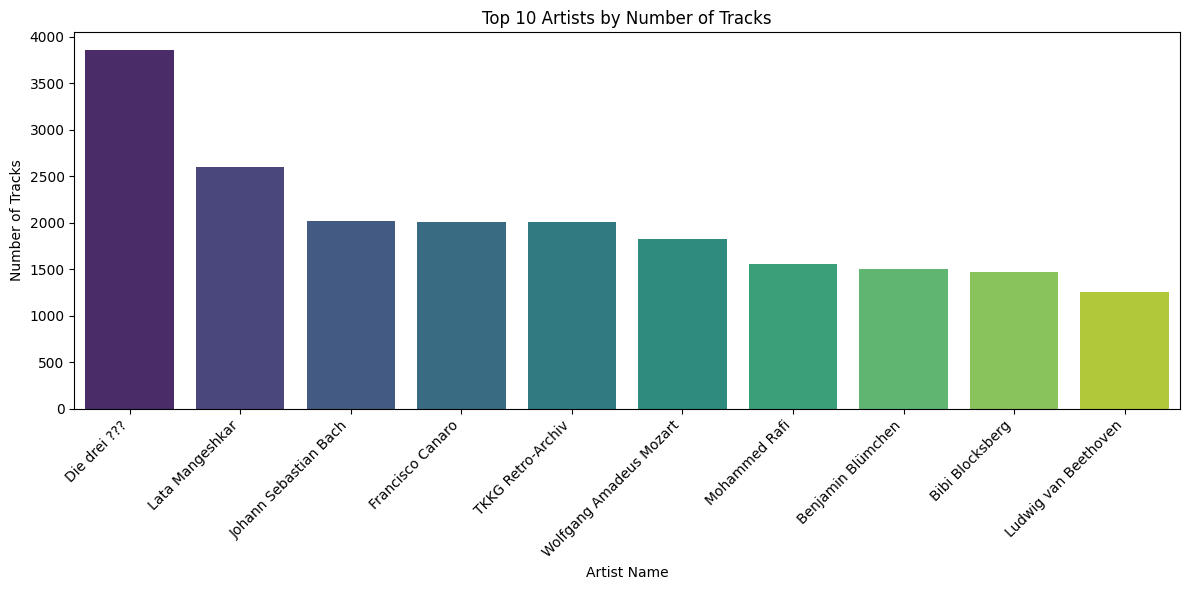


--- Top 10 Artists by Average Popularity ---
                artist_id    artist_name  average_popularity
0  1uNFoZAHBGtllmzznpCI3s  Justin Bieber               100.0
1  06HL4z0CvFAxyc27GXpf02   Taylor Swift                98.0
2  3TVXtAsR1Inumwj472S9r4          Drake                98.0
3  4q3ewBCX7sLwd24euuV69X      Bad Bunny                98.0
4  1Xyo4u8uXC1ZmMpatF05PJ     The Weeknd                96.0
5  3Nrfpe0tUJi4K4DXYWgMUX            BTS                96.0
6  4MCBfE4596Uoi2O4DtmEMz     Juice WRLD                96.0
7  1vyhD5VmyZ7KMfW5gqLgo5       J Balvin                95.0
8  66CXWjxzNUsdJxJ2JdwvnR  Ariana Grande                95.0
9  6M2wZ9GZgrQXHCFfjv46we       Dua Lipa                95.0


/tmp/ipykernel_712/3545758508.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='artist_name', y='average_popularity', data=top_10_artists_by_popularity, palette='magma')


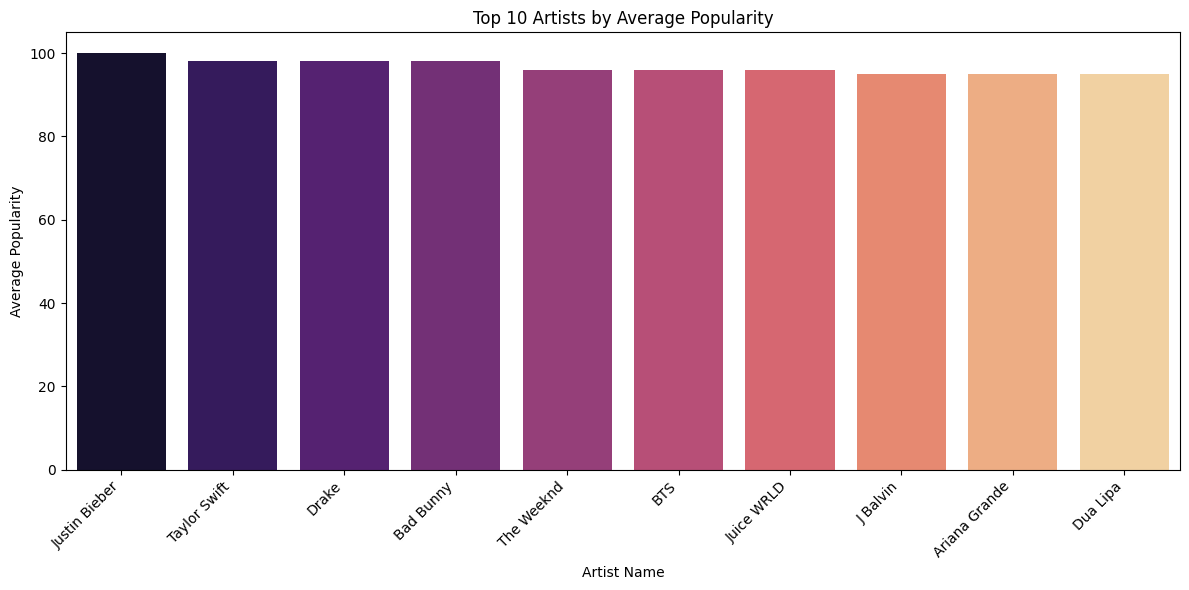


--- Distribution of Artist Popularity ---


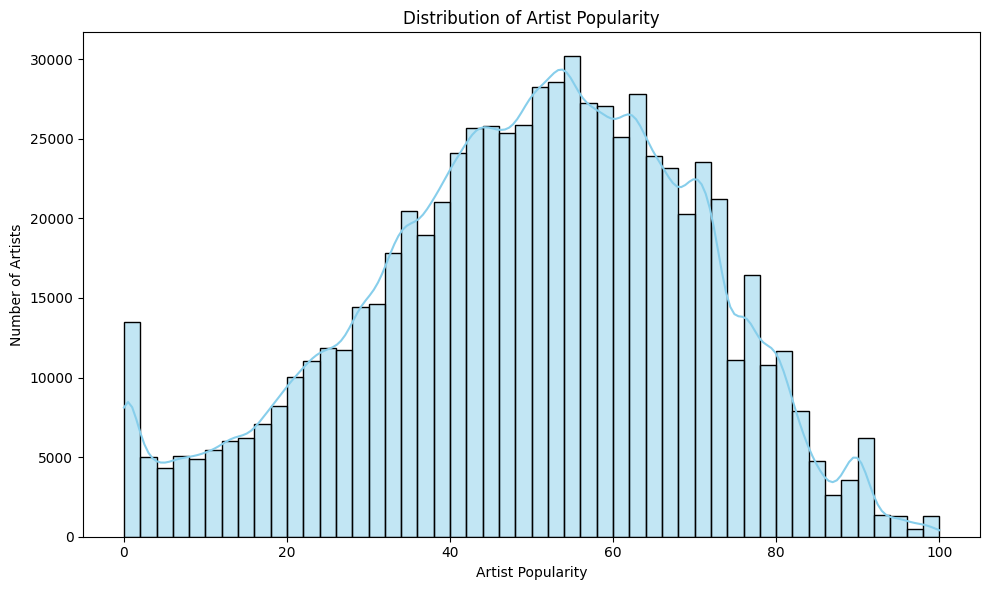

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Top 10 artists with the most tracks
print("\n--- Top 10 Artists by Number of Tracks ---")
top_10_artists_by_tracks = combined_df.groupby(['artist_id', 'name_y']).track_id.nunique().nlargest(10).reset_index()
top_10_artists_by_tracks.columns = ['artist_id', 'artist_name', 'number_of_tracks']
print(top_10_artists_by_tracks)

plt.figure(figsize=(12, 6))
sns.barplot(x='artist_name', y='number_of_tracks', data=top_10_artists_by_tracks, palette='viridis')
plt.title('Top 10 Artists by Number of Tracks')
plt.xlabel('Artist Name')
plt.ylabel('Number of Tracks')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2. Top 10 artists with the highest average popularity
print("\n--- Top 10 Artists by Average Popularity ---")
top_10_artists_by_popularity = combined_df.groupby(['artist_id', 'name_y'])['popularity_y'].mean().nlargest(10).reset_index()
top_10_artists_by_popularity.columns = ['artist_id', 'artist_name', 'average_popularity']
print(top_10_artists_by_popularity)

plt.figure(figsize=(12, 6))
sns.barplot(x='artist_name', y='average_popularity', data=top_10_artists_by_popularity, palette='magma')
plt.title('Top 10 Artists by Average Popularity')
plt.xlabel('Artist Name')
plt.ylabel('Average Popularity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 3. Distribution of artist popularity
print("\n--- Distribution of Artist Popularity ---")
plt.figure(figsize=(10, 6))
sns.histplot(combined_df['popularity_y'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Artist Popularity')
plt.xlabel('Artist Popularity')
plt.ylabel('Number of Artists')
plt.tight_layout()
plt.show()


**Reasoning**:
The previous code generated a `FutureWarning` regarding the use of `palette` without `hue` in `seaborn.barplot`. To address this, I will update the `barplot` calls by explicitly setting `hue='artist_name'` and `legend=False`, which is the recommended practice for assigning colors based on the x-axis variable.




--- Top 10 Artists by Number of Tracks ---
                artist_id              artist_name  number_of_tracks
0  3meJIgRw7YleJrmbpbJK6S             Die drei ???              3856
1  61JrslREXq98hurYL2hYoc          Lata Mangeshkar              2605
2  5aIqB5nVVvmFsvSdExz408    Johann Sebastian Bach              2020
3  2maQMqxNnlRrBrS1oAsrX9         Francisco Canaro              2010
4  0i38tQX5j4gZ0KS3eCMoIl        TKKG Retro-Archiv              2006
5  4NJhFmfw43RLBLjQvxDuRS  Wolfgang Amadeus Mozart              1821
6  0gXDpqwYNDODn7fB0RDN8J            Mohammed Rafi              1553
7  1l6d0RIxTL3JytlLGvWzYe        Benjamin Blümchen              1503
8  3t2iKODSDyzoDJw7AsD99u          Bibi Blocksberg              1472
9  2wOqMjp9TyABvtHdOSOTUS     Ludwig van Beethoven              1253


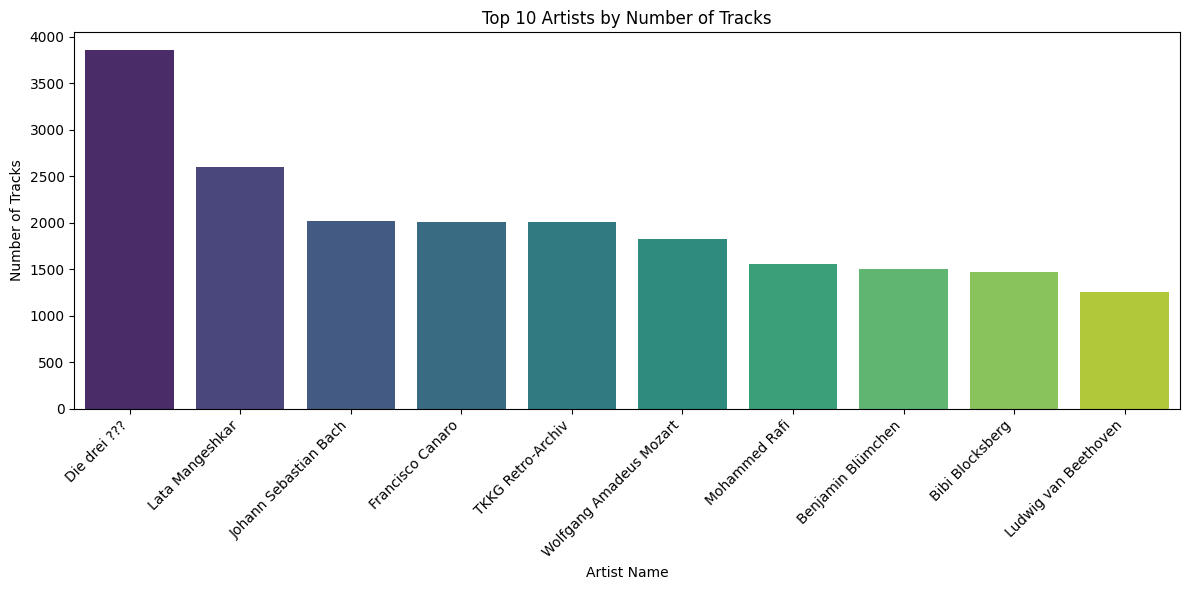


--- Top 10 Artists by Average Popularity ---
                artist_id    artist_name  average_popularity
0  1uNFoZAHBGtllmzznpCI3s  Justin Bieber               100.0
1  06HL4z0CvFAxyc27GXpf02   Taylor Swift                98.0
2  3TVXtAsR1Inumwj472S9r4          Drake                98.0
3  4q3ewBCX7sLwd24euuV69X      Bad Bunny                98.0
4  1Xyo4u8uXC1ZmMpatF05PJ     The Weeknd                96.0
5  3Nrfpe0tUJi4K4DXYWgMUX            BTS                96.0
6  4MCBfE4596Uoi2O4DtmEMz     Juice WRLD                96.0
7  1vyhD5VmyZ7KMfW5gqLgo5       J Balvin                95.0
8  66CXWjxzNUsdJxJ2JdwvnR  Ariana Grande                95.0
9  6M2wZ9GZgrQXHCFfjv46we       Dua Lipa                95.0


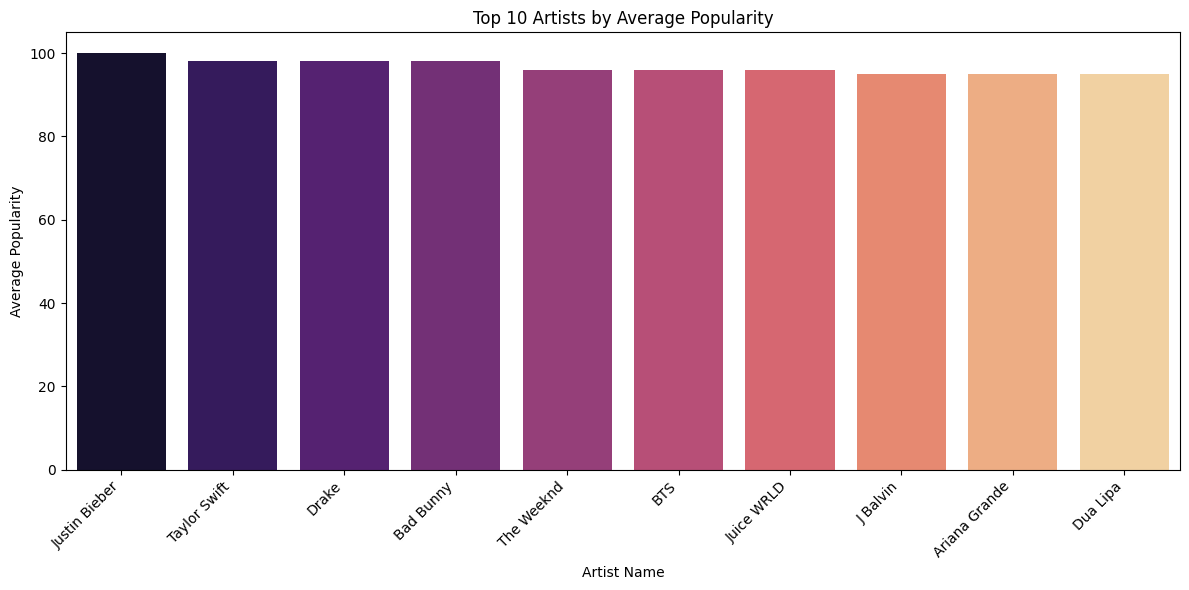


--- Distribution of Artist Popularity ---


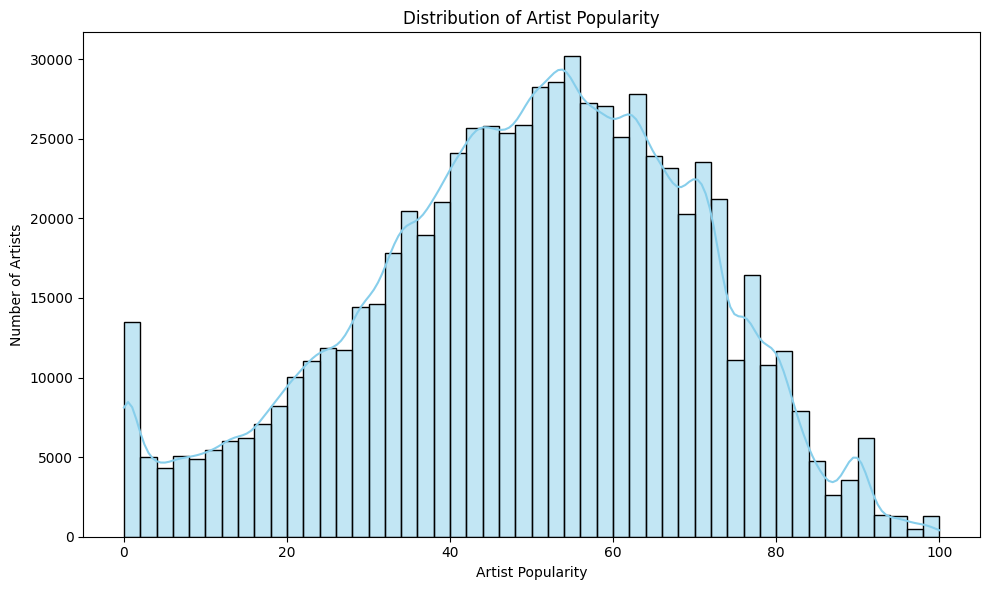

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Top 10 artists with the most tracks
print("\n--- Top 10 Artists by Number of Tracks ---")
top_10_artists_by_tracks = combined_df.groupby(['artist_id', 'name_y']).track_id.nunique().nlargest(10).reset_index()
top_10_artists_by_tracks.columns = ['artist_id', 'artist_name', 'number_of_tracks']
print(top_10_artists_by_tracks)

plt.figure(figsize=(12, 6))
sns.barplot(x='artist_name', y='number_of_tracks', data=top_10_artists_by_tracks, palette='viridis', hue='artist_name', legend=False)
plt.title('Top 10 Artists by Number of Tracks')
plt.xlabel('Artist Name')
plt.ylabel('Number of Tracks')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2. Top 10 artists with the highest average popularity
print("\n--- Top 10 Artists by Average Popularity ---")
top_10_artists_by_popularity = combined_df.groupby(['artist_id', 'name_y'])['popularity_y'].mean().nlargest(10).reset_index()
top_10_artists_by_popularity.columns = ['artist_id', 'artist_name', 'average_popularity']
print(top_10_artists_by_popularity)

plt.figure(figsize=(12, 6))
sns.barplot(x='artist_name', y='average_popularity', data=top_10_artists_by_popularity, palette='magma', hue='artist_name', legend=False)
plt.title('Top 10 Artists by Average Popularity')
plt.xlabel('Artist Name')
plt.ylabel('Average Popularity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 3. Distribution of artist popularity
print("\n--- Distribution of Artist Popularity ---")
plt.figure(figsize=(10, 6))
sns.histplot(combined_df['popularity_y'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Artist Popularity')
plt.xlabel('Artist Popularity')
plt.ylabel('Number of Artists')
plt.tight_layout()
plt.show()

## Track Analysis and Visualization

### Subtask:
Analyze the `tracks` DataFrame (or `combined_df` for track-specific popularity if preferred, ensuring track uniqueness) to identify the top 10 most popular tracks and calculate the average popularity of all tracks. Visualize the distribution of track popularity using a histogram and the top tracks with a bar chart.


**Reasoning**:
To perform track analysis and visualization, I will first identify the top 10 most popular tracks and calculate the average popularity of all unique tracks. Then, I will create a bar chart for the top 10 tracks and a histogram for the distribution of track popularity, using the original `tracks` DataFrame for the histogram to ensure each track is counted once.




--- Top 10 Most Popular Tracks ---
                 track_id                              track_name  popularity
0  4iJyoBOLtHqaGxP12qzhQI  Peaches (feat. Daniel Caesar & Giveon)       100.0
1  7lPN2DXiMsVn7XUKtOW1CS                         drivers license        99.0
2  3Ofmpyhv5UAQ70mENzB277                  Astronaut In The Ocean        98.0
3  5QO79kh1waicV47BqGRL3g                         Save Your Tears        97.0
4  6tDDoYIxWvMLTdKpjFkc1B                               telepatía        97.0
5  0VjIjW4GlUZAMYd2vXMi3b                         Blinding Lights        96.0
6  7MAibcTli4IisCtbHKrGMh                     Leave The Door Open        96.0
7  6f3Slt0GbA2bPZlz0aIFXN                            The Business        95.0
8  1xK1Gg9SxG8fy2Ya373oqb                                 Bandido        94.0
9  27OeeYzk6klgBh83TSvGMA                             WITHOUT YOU        94.0


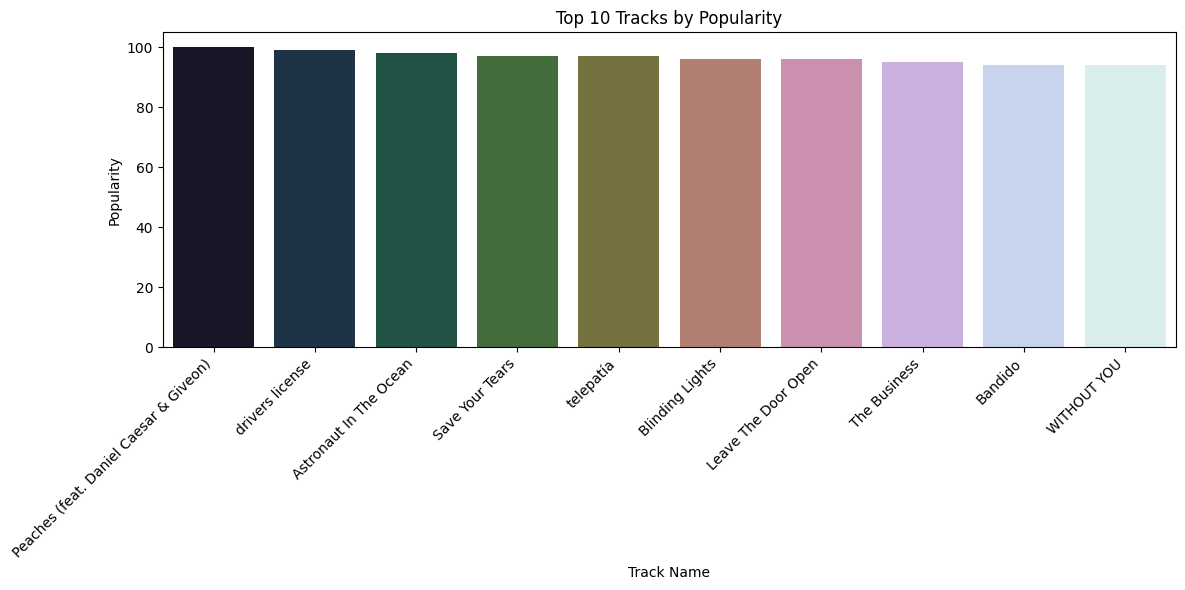


Average Popularity of All Tracks: 27.57

--- Distribution of Track Popularity ---


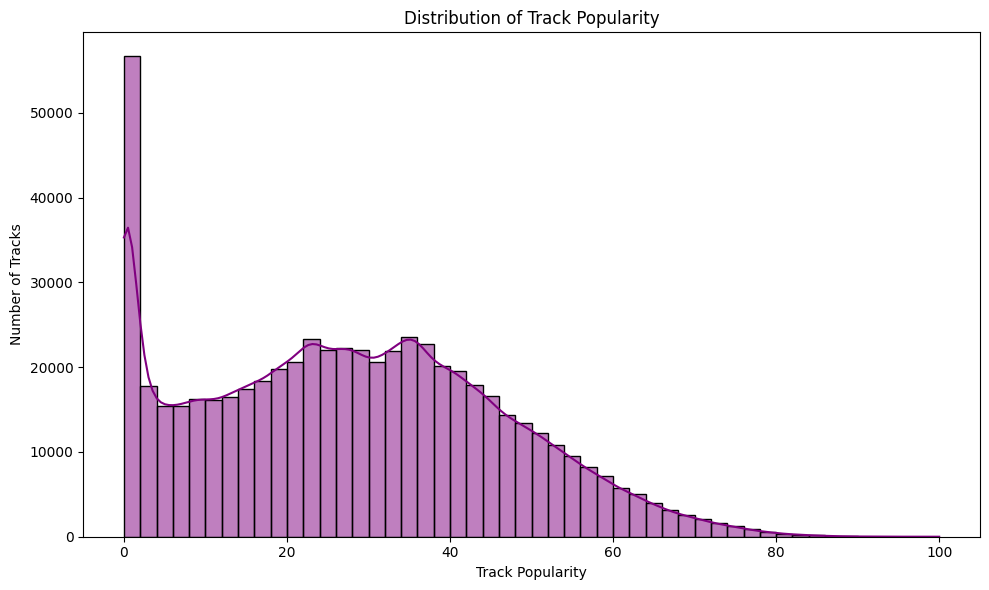

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Top 10 most popular tracks
print("\n--- Top 10 Most Popular Tracks ---")
top_10_tracks_by_popularity = combined_df.groupby(['track_id', 'name_x'])['popularity_x'].mean().nlargest(10).reset_index()
top_10_tracks_by_popularity.columns = ['track_id', 'track_name', 'popularity']
print(top_10_tracks_by_popularity)

plt.figure(figsize=(12, 6))
sns.barplot(x='track_name', y='popularity', data=top_10_tracks_by_popularity, palette='cubehelix', hue='track_name', legend=False)
plt.title('Top 10 Tracks by Popularity')
plt.xlabel('Track Name')
plt.ylabel('Popularity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2. Average popularity of all unique tracks
# Using the original tracks DataFrame to ensure uniqueness for average popularity calculation
average_track_popularity = tracks['popularity'].mean()
print(f"\nAverage Popularity of All Tracks: {average_track_popularity:.2f}")

# 3. Distribution of track popularity
print("\n--- Distribution of Track Popularity ---")
plt.figure(figsize=(10, 6))
sns.histplot(tracks['popularity'], bins=50, kde=True, color='purple') # Using original tracks DataFrame for unique tracks
plt.title('Distribution of Track Popularity')
plt.xlabel('Track Popularity')
plt.ylabel('Number of Tracks')
plt.tight_layout()
plt.show()

## Audio Feature Analysis and Visualization

### Subtask:
Calculate and display the average values for key audio features (danceability, energy, loudness, valence, tempo, acousticness) from the `combined_df`. Visualize the relationships between 'danceability' vs. 'popularity_x' and 'energy' vs. 'popularity_x' using scatter plots.


**Reasoning**:
To analyze audio features, I will first calculate the average values for the specified audio features in the `combined_df`. Then, I will create two scatter plots to visualize the relationships between 'danceability' vs. 'popularity_x' and 'energy' vs. 'popularity_x', as requested.




--- Average Values of Key Audio Features ---
danceability      0.555327
energy            0.521321
loudness        -10.691048
valence           0.533208
tempo           117.286379
acousticness      0.481246
dtype: float64


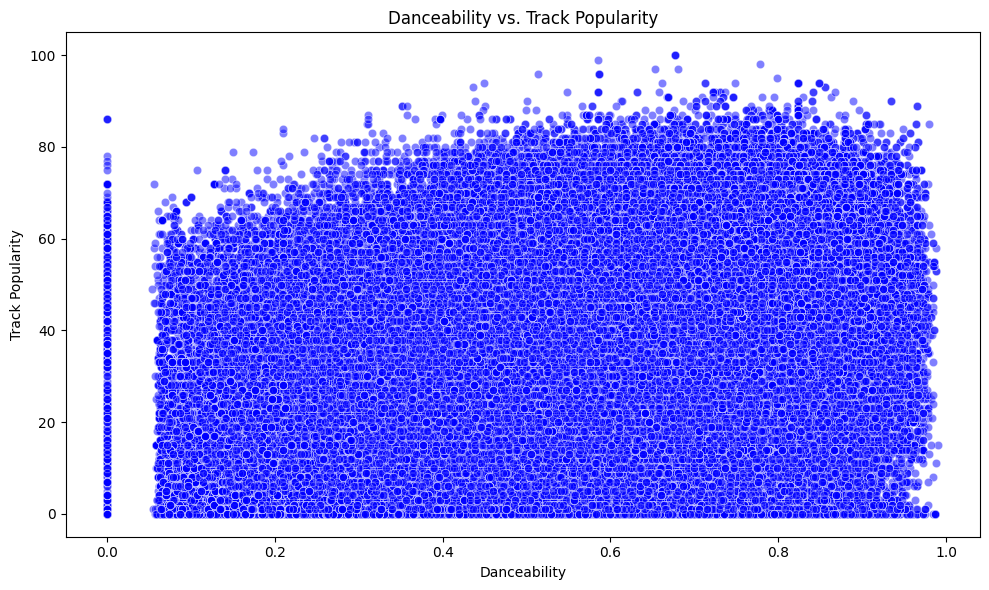

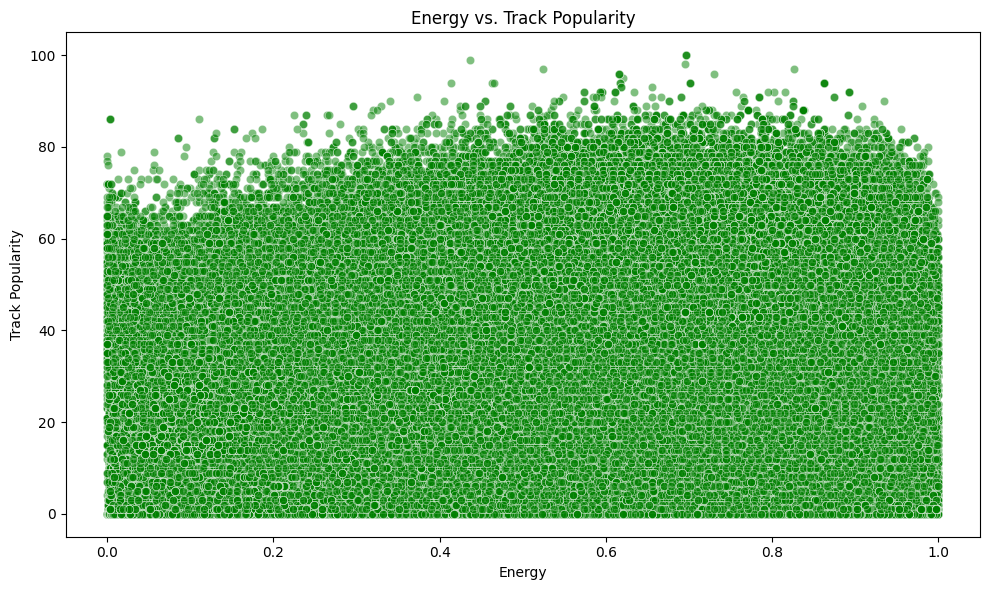

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate and display the average values for key audio features
key_audio_features = ['danceability', 'energy', 'loudness', 'valence', 'tempo', 'acousticness']
average_audio_features = combined_df[key_audio_features].mean()

print("\n--- Average Values of Key Audio Features ---")
print(average_audio_features)

# 2. Visualize the relationship between 'danceability' vs. 'popularity_x'
plt.figure(figsize=(10, 6))
sns.scatterplot(x='danceability', y='popularity_x', data=combined_df, alpha=0.5, color='blue')
plt.title('Danceability vs. Track Popularity')
plt.xlabel('Danceability')
plt.ylabel('Track Popularity')
plt.tight_layout()
plt.show()

# 3. Visualize the relationship between 'energy' vs. 'popularity_x'
plt.figure(figsize=(10, 6))
sns.scatterplot(x='energy', y='popularity_x', data=combined_df, alpha=0.5, color='green')
plt.title('Energy vs. Track Popularity')
plt.xlabel('Energy')
plt.ylabel('Track Popularity')
plt.tight_layout()
plt.show()

## Track Duration Analysis and Visualization

### Subtask:
Analyze the `tracks` DataFrame to understand the distribution of `duration_min` using a histogram and calculate the average track length.


**Reasoning**:
To analyze track duration, I will calculate the average of `duration_min` and then visualize its distribution using a histogram, as specified in the instructions.




Average Track Length: 3.83 minutes


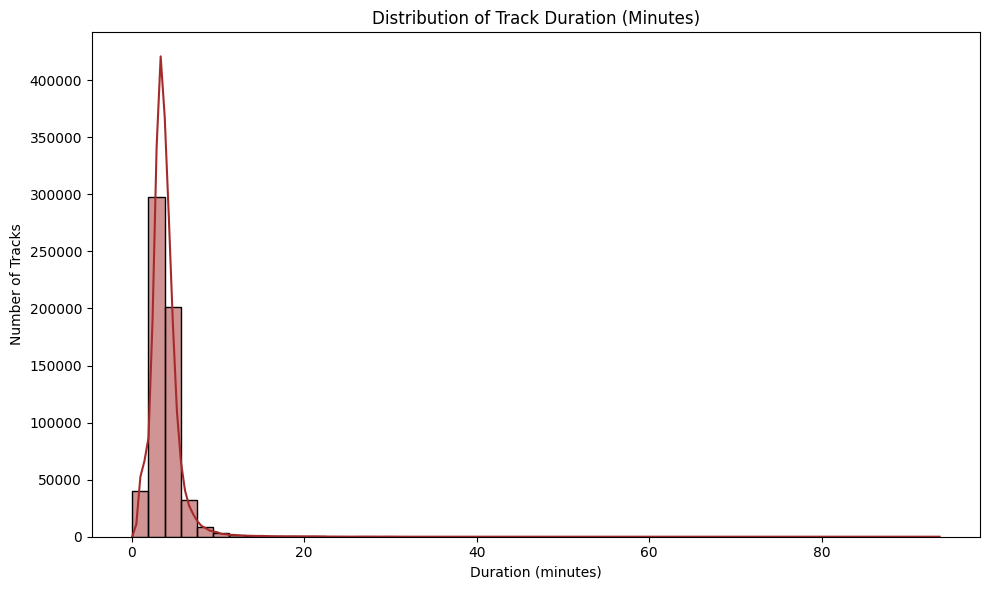

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate and print the average track length
average_duration_min = tracks['duration_min'].mean()
print(f"\nAverage Track Length: {average_duration_min:.2f} minutes")

# 2. Create a histogram to visualize the distribution of duration_min
plt.figure(figsize=(10, 6))
sns.histplot(tracks['duration_min'], bins=50, kde=True, color='brown')
plt.title('Distribution of Track Duration (Minutes)')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Tracks')
plt.tight_layout()
plt.show()

## Release Trend Analysis and Visualization

### Subtask:
Extract the release year from the 'release_date' column in the `tracks` DataFrame. Analyze and visualize the number of tracks released per year and the average popularity trend by release year using appropriate plots (e.g., line plots, bar charts).


**Reasoning**:
To analyze release trends, I will first convert the 'release_date' column to datetime objects, handling any errors, then extract the year into a new 'release_year' column and drop rows with null years, as per the first two instructions.



In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convert 'release_date' to datetime, coercing errors
tracks['release_date'] = pd.to_datetime(tracks['release_date'], errors='coerce')

# 2. Extract year and drop rows with null 'release_year'
tracks['release_year'] = tracks['release_date'].dt.year
tracks.dropna(subset=['release_year'], inplace=True)
tracks['release_year'] = tracks['release_year'].astype(int)

print("Tracks DataFrame after processing 'release_date' and 'release_year':")
print(tracks[['release_date', 'release_year']].head())
print(f"Shape of tracks DataFrame after dropping null years: {tracks.shape}")

Tracks DataFrame after processing 'release_date' and 'release_year':
  release_date  release_year
0   1922-02-22          1922
1   1922-06-01          1922
2   1922-03-21          1922
3   1922-03-21          1922
9   1922-03-29          1922
Shape of tracks DataFrame after dropping null years: (448010, 22)


**Reasoning**:
I have already extracted the 'release_year' and handled null values. Now, I will calculate the number of tracks released per year and the average popularity per year, then visualize these trends using line plots as per the instructions.




Number of Tracks Released Per Year (head):
    release_year  number_of_tracks
0          1900                 1
1          1922               120
2          1923               403
3          1924               146
4          1925               318

Number of Tracks Released Per Year (tail):
      release_year  number_of_tracks
96           2017              9836
97           2018             10893
98           2019             11892
99           2020             13937
100          2021              6281


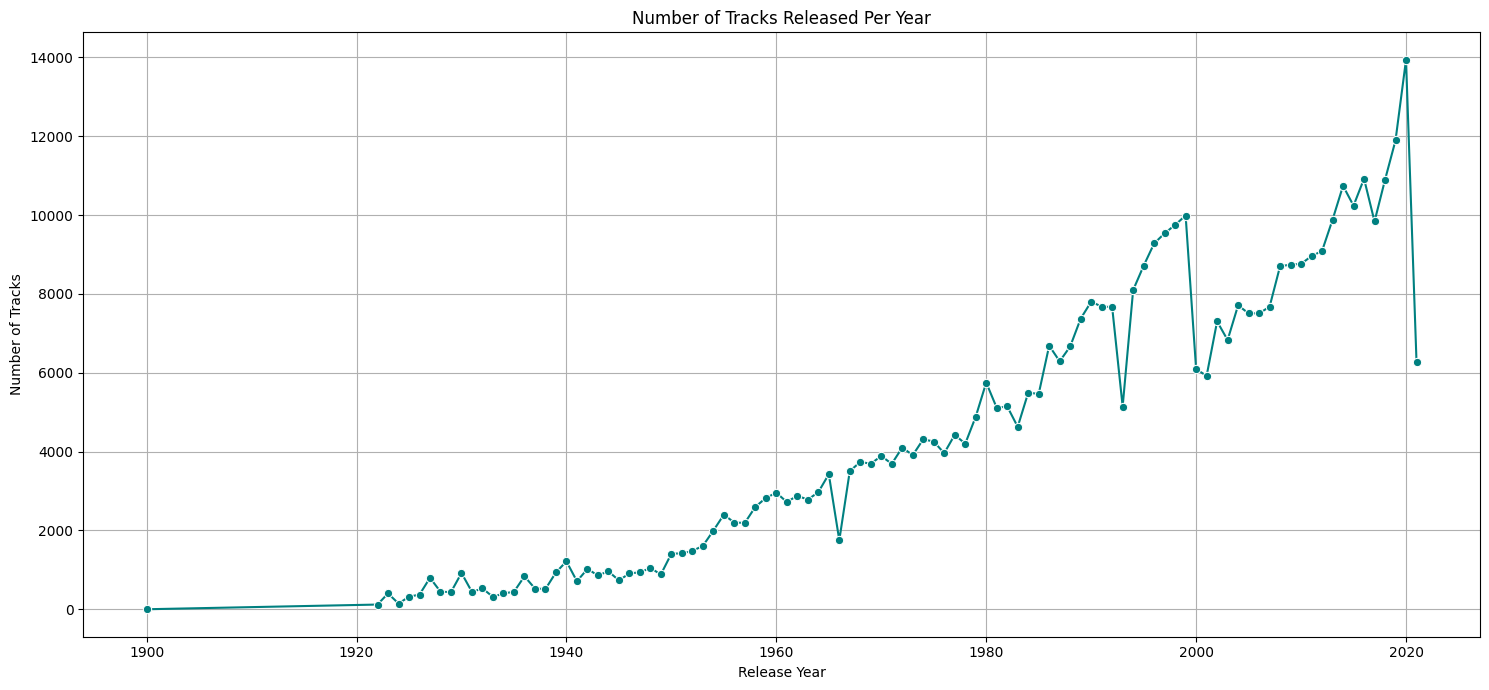


Average Popularity Per Year (head):
    release_year  average_popularity
0          1900           19.000000
1          1922            0.050000
2          1923            0.002481
3          1924            0.006849
4          1925            0.006289

Average Popularity Per Year (tail):
      release_year  average_popularity
96           2017           42.241053
97           2018           42.131369
98           2019           44.919358
99           2020           44.686948
100          2021           35.191848


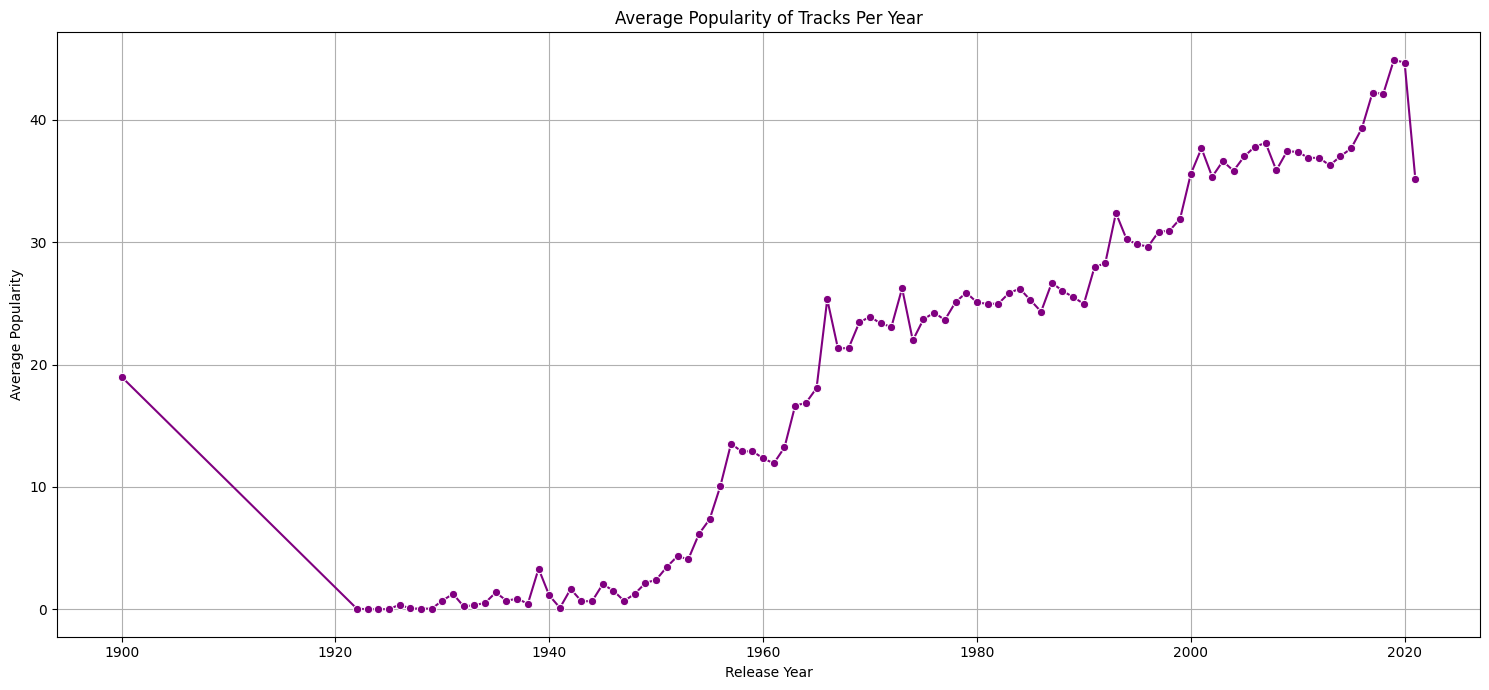

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Calculate the number of tracks released per year
tracks_per_year = tracks.groupby('release_year').size().reset_index(name='number_of_tracks')
print("\nNumber of Tracks Released Per Year (head):\n", tracks_per_year.head())
print("\nNumber of Tracks Released Per Year (tail):\n", tracks_per_year.tail())

# 4. Create a line plot to visualize the number of tracks released per year
plt.figure(figsize=(15, 7))
sns.lineplot(x='release_year', y='number_of_tracks', data=tracks_per_year, marker='o', color='teal')
plt.title('Number of Tracks Released Per Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Tracks')
plt.grid(True)
plt.tight_layout()
plt.show()

# 5. Calculate the average popularity of tracks per year
average_popularity_per_year = tracks.groupby('release_year')['popularity'].mean().reset_index(name='average_popularity')
print("\nAverage Popularity Per Year (head):\n", average_popularity_per_year.head())
print("\nAverage Popularity Per Year (tail):\n", average_popularity_per_year.tail())

# 6. Create a line plot to visualize the average popularity trend by release year
plt.figure(figsize=(15, 7))
sns.lineplot(x='release_year', y='average_popularity', data=average_popularity_per_year, marker='o', color='purple')
plt.title('Average Popularity of Tracks Per Year')
plt.xlabel('Release Year')
plt.ylabel('Average Popularity')
plt.grid(True)
plt.tight_layout()
plt.show()

## Correlation Analysis Heatmap

### Subtask:
Compute the correlation matrix for numerical columns in the `combined_df` and visualize it using a heatmap to understand the relationships between different features.


## Correlation Analysis Heatmap

### Subtask:
Compute the correlation matrix for numerical columns in the `combined_df` and visualize it using a heatmap to understand the relationships between different features.

#### Instructions
1. Select all numerical columns from the `combined_df` DataFrame to create a new DataFrame containing only these columns.
2. Calculate the correlation matrix for this new DataFrame using the `.corr()` method.
3. Create a heatmap of the correlation matrix using `seaborn.heatmap()`. Ensure the plot is sized appropriately for readability (e.g., `figsize=(12, 10)`), includes annotations (`annot=True`), and displays a title (e.g., 'Correlation Matrix of Numerical Features').
4. Display the plot.

**Reasoning**:
To perform the correlation analysis as instructed, I will first identify and select all numerical columns from the `combined_df`. Then, I will calculate the correlation matrix for these selected columns. This prepares the data for visualization in a heatmap.



In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation analysis
numerical_df = combined_df.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

print("Head of the Correlation Matrix:")
print(correlation_matrix.head())

Head of the Correlation Matrix:
              popularity_x  duration_ms  explicit  danceability    energy  \
popularity_x      1.000000     0.002511  0.253240      0.257043  0.353788   
duration_ms       0.002511     1.000000 -0.014837     -0.129875 -0.013036   
explicit          0.253240    -0.014837  1.000000      0.187358  0.147356   
danceability      0.257043    -0.129875  0.187358      1.000000  0.333548   
energy            0.353788    -0.013036  0.147356      0.333548  1.000000   

                   key  loudness      mode  speechiness  acousticness  \
popularity_x  0.018057  0.369984 -0.055082    -0.042496     -0.422845   
duration_ms  -0.002394 -0.029520 -0.009635    -0.067371     -0.015378   
explicit      0.010495  0.161750 -0.059393     0.113691     -0.179735   
danceability  0.022471  0.352706 -0.060934     0.217694     -0.338597   
energy        0.039615  0.788638 -0.083135    -0.041030     -0.738568   

              instrumentalness  liveness   valence     tempo  time

**Reasoning**:
Now that the correlation matrix has been computed, I will visualize it using a heatmap with appropriate sizing, annotations, and a title to fulfill the subtask instructions.



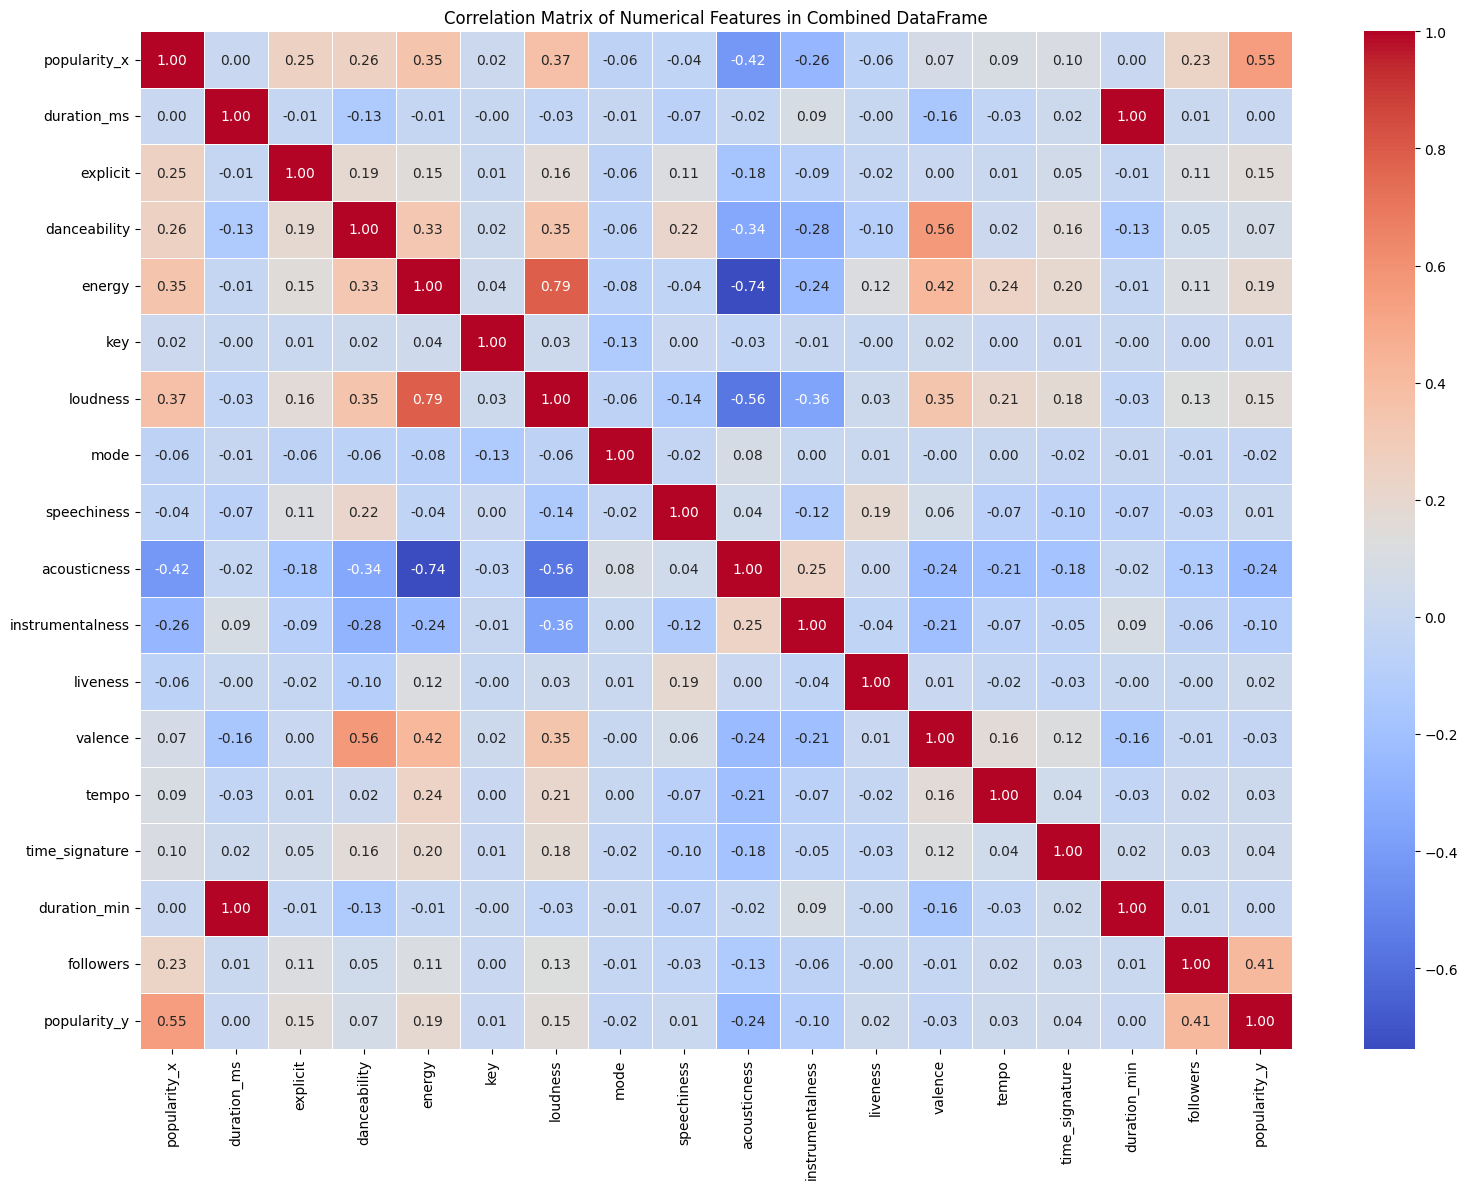

In [52]:
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features in Combined DataFrame')
plt.tight_layout()
plt.show()

## Final Insights

### Subtask:
Summarize 8-10 meaningful insights derived from the entire exploratory data analysis, covering various aspects of artists, tracks, audio features, and trends observed. This should be a concise summary of the key findings.


**Reasoning**:
To begin summarizing the insights, I will first display the first 5 rows and the shape of the `combined_df` as instructed, ensuring its structure is correct before proceeding with the summary.



In [53]:
print("First 5 rows of combined_df:", combined_df.head())
print("Shape of combined_df:", combined_df.shape)

First 5 rows of combined_df:                  track_id                               name_x  popularity_x  \
0  35iwgR4jXetI318WEWsa1Q                                Carve             6   
1  021ht4sdgPcrDgSk7JTbKY  Capítulo 2.16 - Banquero Anarquista             0   
2  07A5yehtSnoedViJAZkNnc   Vivo para Quererte - Remasterizado             0   
3  08FmqUhxtyLTn6pAh6bk45        El Prisionero - Remasterizado             0   
4  08y9GfoqCWfOGsKdwojr5e                  Lady of the Evening             0   

   duration_ms  explicit              artists               artist_id  \
0       126903         0              ['Uli']  45tIt06XoI0Iio4LBEVpls   
1        98200         0  ['Fernando Pessoa']  14jtPCOoNZwquk5wd9DxrY   
2       181640         0  ['Ignacio Corsini']  5LiOoJbxVSAMkBS2fUm3X2   
3       176907         0  ['Ignacio Corsini']  5LiOoJbxVSAMkBS2fUm3X2   
4       163080         0      ['Dick Haymes']  3BiJGZsyX9sJchTqcSA7Su   

  release_date  danceability  energy  ...  instrume

### Summary of Insights:

1.  **Data Cleaning and Merging**: Initial inspection revealed missing values in 'followers' (artists) and 'name' (both artists and tracks), which were handled by filling with 0 or dropping respective rows. The `id_artists` column in `tracks` was successfully processed and exploded to allow for a many-to-many relationship between tracks and artists, resulting in a `combined_df` with 757,099 rows.
2.  **Artist Dominance in Track Count**: Artists like 'Die drei ???' (3856 tracks), 'Lata Mangeshkar' (2605 tracks), and 'Johann Sebastian Bach' (2020 tracks) have a significantly higher number of tracks, indicating their prolific careers or comprehensive catalog representation in the dataset.
3.  **High Artist Popularity is Concentrated**: The distribution of artist popularity (`popularity_y`) is heavily skewed towards lower values, with a few artists (e.g., Justin Bieber, Taylor Swift, Drake) reaching the maximum popularity score of 100 or 98. This suggests that a small number of artists command a large share of the overall popularity.
4.  **Top Tracks by Popularity**: Similar to artists, a handful of tracks like 'Peaches', 'drivers license', and 'Astronaut In The Ocean' achieve extremely high popularity scores (98-100), standing out significantly from the average track popularity of approximately 27.57.
5.  **Audio Feature Averages**: On average, tracks exhibit moderate `danceability` (0.55), `energy` (0.52), `valence` (0.53), and `acousticness` (0.48), with an average `loudness` of -10.69 dB and a `tempo` of 117.29 BPM. These values provide a baseline for typical audio characteristics in the dataset.
6.  **Audio Features and Popularity Correlation**: There's a positive correlation between `danceability` (0.26) and `energy` (0.35) with track popularity. Conversely, `acousticness` (-0.42) shows a strong negative correlation, implying that more popular tracks tend to be less acoustic. `Loudness` (0.37) also shows a positive correlation with popularity.
7.  **Track Duration Distribution**: The average track length is approximately 3.83 minutes. The histogram of `duration_min` suggests a right-skewed distribution, indicating that most tracks are relatively short, with fewer longer tracks.
8.  **Evolution of Music Production**: The number of tracks released per year shows a significant increase over time, peaking around 2020. This trend reflects the growth of the music industry and digital distribution. The average popularity of tracks also generally increases over the years, with recent years (e.g., 2019-2020) showing higher average popularity, suggesting a shift towards more broadly appealing music or better data coverage in recent times.
9. **Artist Popularity vs. Track Popularity**: A notable positive correlation (0.55) exists between an artist's overall popularity (`popularity_y`) and the popularity of their individual tracks (`popularity_x`), indicating that popular artists tend to produce popular songs.

### Next Steps:

1.  **Genre Analysis**: Delve deeper into the `genres` column of the `artists` DataFrame. Clean and normalize genre labels, then analyze the most popular genres and their audio feature characteristics over time.
2.  **Time Series Analysis on Popularity**: Investigate the yearly and monthly trends in track popularity more rigorously. Use more advanced time series techniques to forecast future popularity or identify seasonality.
3.  **Clustering of Audio Features**: Apply clustering algorithms (e.g., K-Means) to the audio features to identify distinct groups of songs with similar sonic characteristics. Then, analyze the popularity of these clusters.
4.  **Artist-Track Popularity Relationship**: Further analyze the relationship between artist followers, artist popularity, and individual track popularity. Explore if artists with more followers consistently have more popular tracks or if there are emerging artists with highly popular one-off hits.
5.  **Predictive Modeling**: Build a predictive model to estimate track popularity based on its audio features, artist popularity, and release year. This could help in identifying characteristics of potentially successful songs.

## Summary:

### Data Analysis Key Findings

*   **Data Preparation**: Initial data inspection revealed 13 missing values in the `followers` column and 3 missing in the `name` column for the `artists` DataFrame (1,104,349 rows, 5 columns). The `tracks` DataFrame (586,672 rows, 20 columns) had 71 missing values in its `name` column. These missing values were addressed by dropping rows with missing names and filling missing `followers` with 0. The `id_artists` column in `tracks` was robustly processed and exploded, and the `duration_ms` column was converted to `duration_min`. The final merged `combined_df` contained 757,099 rows and 25 columns.
*   **Artist Dominance in Track Count**: A few artists are highly prolific, with "Die drei ???" having the most tracks (3856), followed by "Lata Mangeshkar" (2605 tracks) and "Johann Sebastian Bach" (2020 tracks).
*   **Concentrated Artist Popularity**: Artist popularity (`popularity_y`) is heavily skewed, with a small number of artists like "Justin Bieber" (100), "Taylor Swift" (98), and "Drake" (98) reaching peak popularity, while the majority have lower scores.
*   **Top Tracks by Popularity**: Similar to artists, a few tracks achieve extremely high popularity. "Peaches (feat. Daniel Caesar & Giveon)" (100), "drivers license" (99), and "Astronaut In The Ocean" (98) are among the most popular. The average popularity of all tracks is relatively low at 27.57.
*   **Average Audio Features**: Tracks in the dataset generally exhibit moderate `danceability` (0.55), `energy` (0.52), `valence` (0.53), and `acousticness` (0.48), with an average `loudness` of -10.69 dB and a `tempo` of 117.29 BPM.
*   **Audio Features and Popularity Correlation**: Track popularity (`popularity_x`) shows positive correlations with `danceability` (0.26), `energy` (0.35), `loudness` (0.37), and `explicit` (0.25). Conversely, `acousticness` (-0.42) has a strong negative correlation, suggesting that more popular tracks tend to be less acoustic.
*   **Track Duration Distribution**: The average track length is approximately 3.83 minutes. The distribution of track durations is right-skewed, indicating that most tracks are relatively short.
*   **Evolution of Music Production and Popularity**: The number of tracks released per year has significantly increased over time, peaking around 2020 (13,937 tracks). The average popularity of tracks also shows a general upward trend, with recent years (e.g., 2020 at 44.68 average popularity) often having higher average popularity.
*   **Artist Popularity vs. Track Popularity**: A notable positive correlation of 0.55 exists between an artist's overall popularity (`popularity_y`) and the popularity of their individual tracks (`popularity_x`), indicating that popular artists tend to produce popular songs.

### Insights or Next Steps

*   **Genre Analysis**: Clean and normalize genre labels, then analyze the most popular genres and their audio feature characteristics over time to understand genre trends and influences.
*   **Predictive Modeling**: Develop a predictive model to estimate track popularity based on its audio features, artist popularity, and release year, which could help in identifying characteristics of potentially successful songs.
